# Linear Systems, Impulse Response & Convolution

Exploring how linear systems transform signals and how convolution is used to calculate the system output.

## Objective

In this notebook, we will:

- Understand the idea of a linear system
- Explore impulse response
- Use convolution to calculate system output
- Observe how different systems affect a signal

## Theory

A system takes an input signal and produces an output signal:

$$
x[n] \rightarrow \boxed{\text{System}} \rightarrow y[n]
$$

For a linear time-invariant (LTI) system, the output can be found using convolution:

$$
y[n] = x[n] * h[n]
$$

where:

- $x[n]$ = input signal
- $h[n]$ = impulse response
- $y[n]$ = output signal

The impulse response $h[n]$ is the output of a system when the input is a unit impulse:

$$
x[n] = \delta[n]
$$

The impulse response completely characterizes an LTI system.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def system(x):
    return 2 * x

In [5]:
x = np.array([1, 2, 3, 4])

y = system(x)

print("Input :", x)
print("Output:", y)

Input : [1 2 3 4]
Output: [2 4 6 8]


In [6]:
x1 = np.array([1, 2, 3])
x2 = np.array([4, 5, 6])

a = 2
b = 3

left = system(a * x1 + b * x2)
right = a * system(x1) + b * system(x2)

print("Left :", left)
print("Right:", right)

Left : [28 38 48]
Right: [28 38 48]


## Observations

- For linear systems, S(ax1​+bx2​)=aS(x1​)+bS(x2​)

In [7]:
N = 11

impulse = np.zeros(N)
impulse[0] = 1

print(impulse)

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


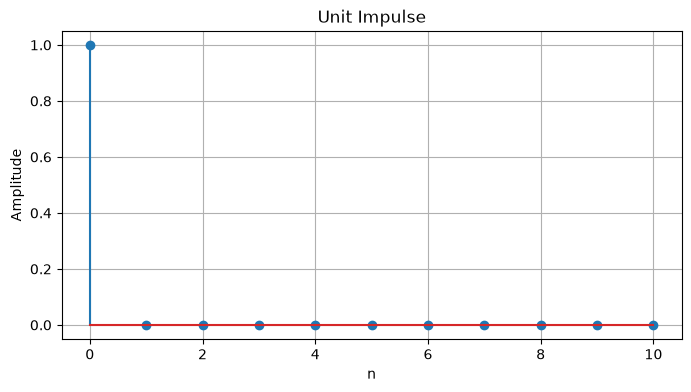

In [8]:
plt.figure(figsize=(8, 4))

plt.stem(impulse)

plt.xlabel("n")
plt.ylabel("Amplitude")
plt.title("Unit Impulse")
plt.grid(True)

plt.show()

In [9]:
def moving_sum(x):
    h = np.array([1, 1, 1])
    return np.convolve(x, h)

In [10]:
y = moving_sum(impulse)

print(y)

[1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


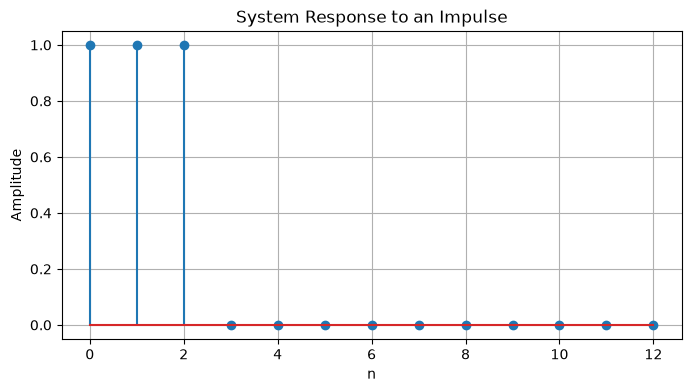

In [11]:
plt.figure(figsize=(8, 4))

plt.stem(y)

plt.xlabel("n")
plt.ylabel("Amplitude")
plt.title("System Response to an Impulse")
plt.grid(True)

plt.show()

## Observations

- If unit impulse is applied as the input signal (x[n]), than output signal (y[n]) = impulse response (h[n])

In [14]:
x = np.array([1, 2, 3, 2, 1])

In [15]:
h = np.array([1, 1, 1])

In [16]:
y = np.convolve(x, h)

print("Input x:", x)
print("Impulse response h:", h)
print("Output y:", y)

Input x: [1 2 3 2 1]
Impulse response h: [1 1 1]
Output y: [1 3 6 7 6 3 1]


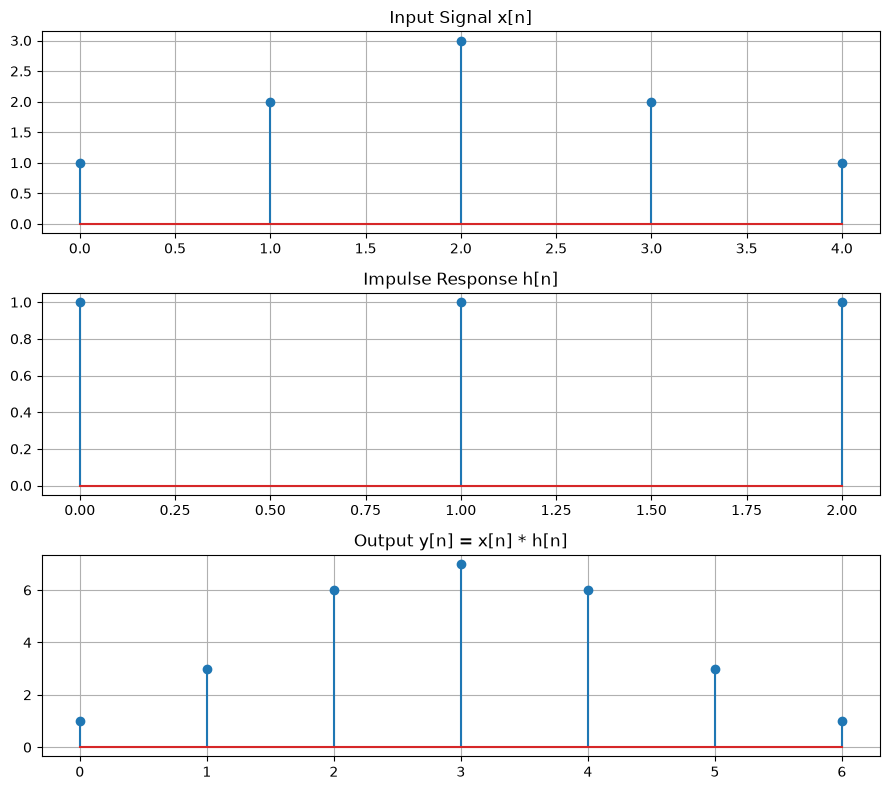

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8))

axes[0].stem(x)
axes[0].set_title("Input Signal x[n]")
axes[0].grid(True)

axes[1].stem(h)
axes[1].set_title("Impulse Response h[n]")
axes[1].grid(True)

axes[2].stem(y)
axes[2].set_title("Output y[n] = x[n] * h[n]")
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Observations

- y[n] = x[n] * h[n] is applied through matrix multiplication.

In [18]:
systems = {
    "Smoothing": np.array([1, 1, 1]) / 3,
    "Weighted": np.array([0.2, 0.6, 0.2]),
    "Differentiator-like": np.array([-1, 1])
}

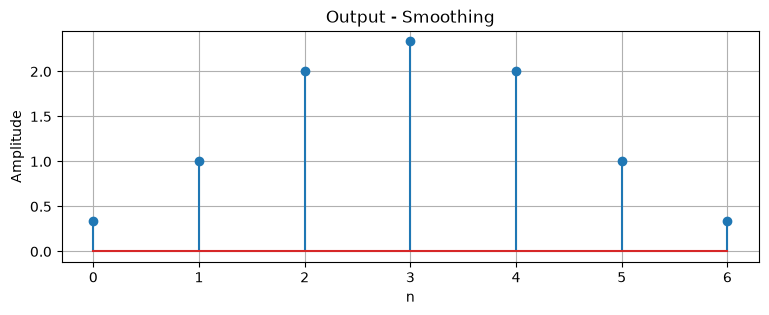

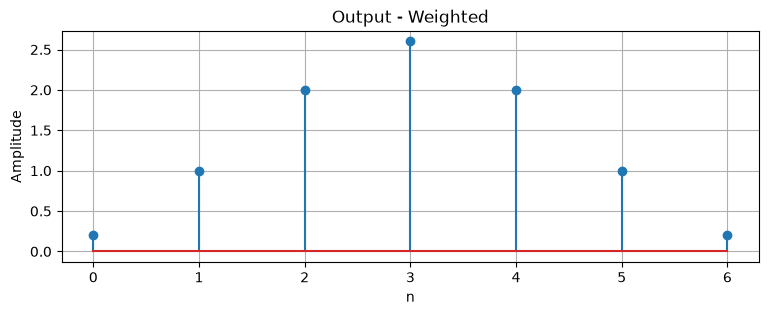

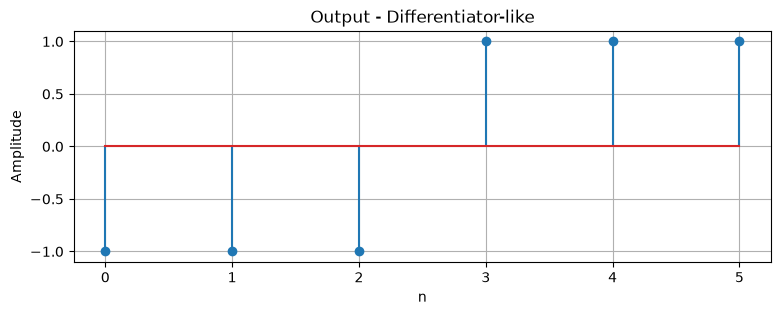

In [19]:
for name, h in systems.items():
    y = np.convolve(x, h)

    plt.figure(figsize=(9, 3))

    plt.stem(y)
    plt.title(f"Output - {name}")
    plt.xlabel("n")
    plt.ylabel("Amplitude")
    plt.grid(True)

    plt.show()

## Observations

- Smoothing system basically makes the steep changes softer.
- Weighted system does a simlar thing but the middle value stands out.
- The differentiator-like system emphasizes changes in the input signal. It produces negative values while the signal is increasing and positive values while it is decreasing.

## Key Takeaways

- A linear system is a collection of linear equations or a mathematical model of a system where the output is directly proportional to the input, following the principle of superposition.
- Impulse response shows how a system reacts over time to an external change.
- Since y[n] is directly proportional to h[n] in linear systems, h[n] becomes very significant for the system to operate in the desired way.
- Convolution is the system calculating the output using input and impulse response.
  

## Next Step

Next, we will study sampling, Nyquist theorem, aliasing, quantization, and ADC fundamentals.